## IMPORTS

In [1]:
from bliss import *

# ============================================================
# 0. Imports and project path
# ============================================================

from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from matplotlib.lines import Line2D
import time

## Victoria load data and helpers

In [2]:
# ============================================================
# Victoria match helper and data
# Chandra ObsID 1928, high-/low-hardness spectra
# ============================================================

def match_victoria_to_candidate_lines_current_run(
    victoria_lines,
    vela_candidate_lines,
    energy_windows,
    obs_pairs,
    tolerance_eV=20.0,
    center_col="center",
    energy_col="energy_obs_keV",
):
    """
    Compare Victoria/Grinberg lines with BLiSS candidate lines from the
    current run stored as vela_candidate_lines[name].

    This version assumes that each candidate table is stored only by
    observation name, not by (observation, window).
    """

    rows = []

    tol_keV = tolerance_eV / 1000.0
    c_km_s = 299792.458

    vic = victoria_lines.copy()
    vic[energy_col] = pd.to_numeric(vic[energy_col], errors="coerce")
    vic = vic[np.isfinite(vic[energy_col])].copy()

    for victoria_obs, our_obs in obs_pairs.items():

        vic_obs = vic[vic["observation"] == victoria_obs].copy()

        if len(vic_obs) == 0:
            print(f"Warning: no Victoria lines found for {victoria_obs}")
            continue

        candidates_all = vela_candidate_lines.get(our_obs, pd.DataFrame())

        if candidates_all is None or len(candidates_all) == 0:
            candidates_all = pd.DataFrame()

        if len(candidates_all) > 0 and center_col in candidates_all.columns:
            candidates_all = candidates_all.copy()
            candidates_all[center_col] = pd.to_numeric(
                candidates_all[center_col],
                errors="coerce",
            )
            candidates_all = candidates_all[
                np.isfinite(candidates_all[center_col])
            ].copy()
        else:
            candidates_all = pd.DataFrame()

        for window_name, (emin, emax) in energy_windows.items():

            # Victoria lines in this energy window
            vic_window = vic_obs[
                (vic_obs[energy_col] >= emin)
                & (vic_obs[energy_col] <= emax)
            ].copy()

            if len(vic_window) == 0:
                continue

            # BLiSS candidates in the same energy window
            if len(candidates_all) > 0:
                candidates = candidates_all[
                    (candidates_all[center_col] >= emin)
                    & (candidates_all[center_col] <= emax)
                ].copy()
            else:
                candidates = pd.DataFrame()

            for _, vrow in vic_window.iterrows():

                Ev = float(vrow[energy_col])

                base = {
                    "victoria_observation": victoria_obs,
                    "our_observation": our_obs,
                    "window": window_name,
                    "window_emin_keV": emin,
                    "window_emax_keV": emax,

                    "element": vrow.get("element", np.nan),
                    "line_id": vrow.get("line_id", np.nan),
                    "line_type": vrow.get("line_type", np.nan),
                    "lambda_obs_A": vrow.get("lambda_obs_A", np.nan),
                    "energy_victoria_keV": Ev,

                    "matched_candidate": False,
                    "match_within_tolerance": False,
                    "candidate_center_keV": np.nan,
                    "delta_E_keV": np.nan,
                    "delta_E_eV": np.nan,
                    "delta_v_km_s": np.nan,
                }

                if len(candidates) == 0:
                    rows.append(base)
                    continue

                delta = candidates[center_col].values - Ev
                abs_delta = np.abs(delta)

                i_best = int(np.argmin(abs_delta))
                best = candidates.iloc[i_best]

                delta_E_keV = float(delta[i_best])
                delta_E_eV = 1000.0 * delta_E_keV
                delta_v_km_s = c_km_s * delta_E_keV / Ev

                out = base.copy()

                out.update(
                    {
                        "matched_candidate": True,
                        "match_within_tolerance": abs(delta_E_keV) <= tol_keV,
                        "candidate_center_keV": float(best[center_col]),
                        "delta_E_keV": delta_E_keV,
                        "delta_E_eV": delta_E_eV,
                        "delta_v_km_s": delta_v_km_s,
                    }
                )

                for col in [
                    "amplitude",
                    "sigma",
                    "snr",
                    "snr_peak",
                    "snr_amplitude",
                    "snr_area",
                    "cluster_probability",
                    "relative_power",
                ]:
                    if col in best.index:
                        out[f"candidate_{col}"] = best[col]

                rows.append(out)

    matches = pd.DataFrame(rows)

    if len(matches) > 0:
        matches = matches.sort_values(
            [
                "victoria_observation",
                "window",
                "energy_victoria_keV",
            ]
        ).reset_index(drop=True)

    return matches

# ============================================================
# Observed line centers from Grinberg et al. 2017, Vela X-1
# Chandra ObsID 1928, high-/low-hardness spectra
# ============================================================

victoria_observed_lines = pd.DataFrame(
    [
        # ----------------------------------------------------
        # HIGH HARDNESS
        # ----------------------------------------------------
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne X Lyβ", "emission", 10.2314],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne X Lyα", "emission", 12.1249],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX r",  "emission", 13.4377],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX i",  "emission", 13.5421],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX f",  "emission", 13.6893],

        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XII Lyα", "emission", 8.4249],
        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI r",    "emission", 9.1732],
        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI i",    "emission", 9.2342],
        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI f",    "emission", 9.3189],

        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si XIV Lyα",        "emission", 6.1787],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si XIII r",         "emission", 6.6442],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si XIII f",         "emission", 6.7365],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si VIII Kα",        "emission", 6.9669],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si VII Kα",         "emission", 7.0237],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si II–VI Kα blend", "emission", 7.1011],


        # ----------------------------------------------------
        # LOW HARDNESS
        # ----------------------------------------------------

        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne X Lyα",  "emission",   12.1354],
        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX r",   "emission",   13.4494],
        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX i",   "emission",   13.5538],
        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX f",   "emission",   13.7011],
        ["Chandra low-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI r",   "emission",   9.1650],
        ["Chandra low-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI i",   "emission",   9.2259],
        ["Chandra low-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI f",   "emission",   9.3105],
        ["Chandra low-hardness", "si_1p65_2p15keV", "Si", "Si XIII f",              "emission", 6.7383],
        ["Chandra low-hardness", "si_1p65_2p15keV", "Si", "unidentified 7.022 Å",   "complex",  7.0220]],
    columns=[
        "observation",
        "window",
        "element",
        "line_id",
        "line_type",
        "lambda_obs_A",
    ],
)

# Convert observed wavelength to observed energy.
victoria_observed_lines["energy_obs_keV"] = (
    12.398419843320026 / victoria_observed_lines["lambda_obs_A"]
)

# Optional: prettier ordering
victoria_lines = victoria_observed_lines[
    [
        "observation",
        "window",
        "element",
        "line_id",
        "line_type",
        "lambda_obs_A",
        "energy_obs_keV",
    ]
].copy()

#victoria_observed_lines


# ------------------------------------------------------------
# Energy windows from the Victoria/Chandra comparison
# ------------------------------------------------------------

energy_windows_victoria = {
    "ne_0p90_1p25keV": (0.90, 1.25),
    "mg_1p25_1p55keV": (1.25, 1.55),
    "si_1p65_2p15keV": (1.65, 2.15),
    "fe_6p0_7p5keV":   (6.35, 7.20),
}

# ------------------------------------------------------------
# Correct observation mapping
# ------------------------------------------------------------

obs_pairs = {
    "Chandra high-hardness": "Chandra high-hardness",
    "Chandra low-hardness": "Chandra low-hardness",
}

# ------------------------------------------------------------
# First three Victoria windows
# ------------------------------------------------------------

first_three_window_names = list(energy_windows_victoria.keys())[:3]

energy_windows_first3 = {
    w: energy_windows_victoria[w]
    for w in first_three_window_names
}

energy_windows_first3

{'ne_0p90_1p25keV': (0.9, 1.25),
 'mg_1p25_1p55keV': (1.25, 1.55),
 'si_1p65_2p15keV': (1.65, 2.15)}

### Load spectra: Chandra Victora & XRISM Camille, calculate baseline and rebin for visualization purposes

Chandra high-hardness: 1579 bins, rebin = 0.0100 keV
Chandra low-hardness: 3278 bins, rebin = 0.0100 keV
XRISM: 14215 bins, rebin = 0.0100 keV


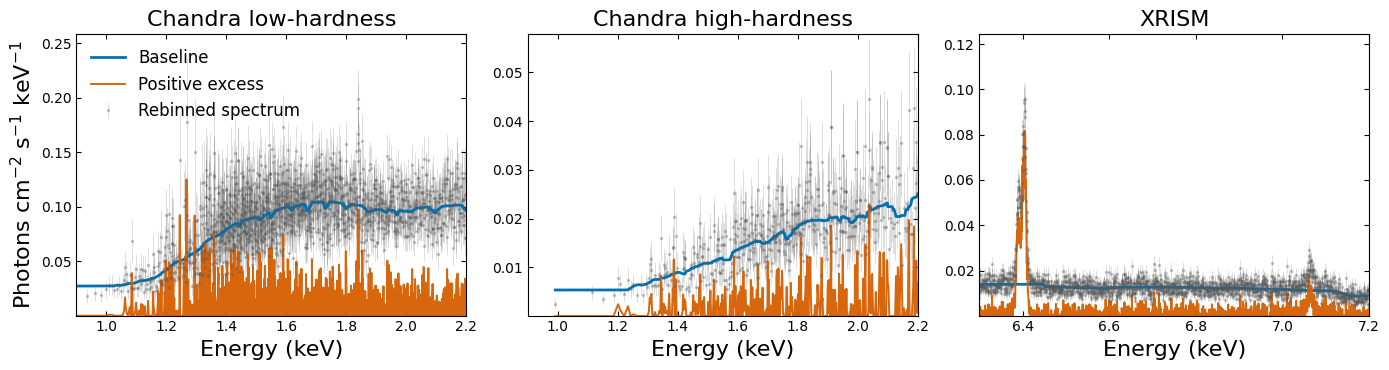

In [4]:
# ============================================================
# Load and rebin Vela X-1 spectra
# ============================================================
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BLISS_DIR = Path("/Users/graciela/Desktop/git/BLiSS")
NOTEBOOKS_DIR = BLISS_DIR / "notebooks"

vela_paths = {
    "Chandra high-hardness": NOTEBOOKS_DIR /  "spec_chh.dat",
    "Chandra low-hardness":  NOTEBOOKS_DIR / "spec_chl.dat",
    "XRISM":                 NOTEBOOKS_DIR /  "spec_xr.dat",
}

# ------------------------------------------------------------
# Rebinning values
# ------------------------------------------------------------

rebin_values = {
    "Chandra high-hardness": 0.01,
    "Chandra low-hardness":  0.01,
    "XRISM":                 0.01,
}

# ------------------------------------------------------------
# Load, clean, sort and rebin
# ------------------------------------------------------------

vela_spectra = {}

for name, path in vela_paths.items():

    loaded = load_text_spectrum(path)

    energy = np.asarray(loaded[0], dtype=float)
    values = np.asarray(loaded[1], dtype=float)
    errors = np.asarray(loaded[2], dtype=float)

    valid = (
        np.isfinite(energy)
        & np.isfinite(values)
        & np.isfinite(errors)
        & (errors > 0)
    )

    energy = energy[valid]
    values = values[valid]
    errors = errors[valid]

    order = np.argsort(energy)
    
    energy = energy[order]
    values = values[order]
    errors = errors[order]

    resolution = rebin_values[name]

    #energy, values, errors = rebin_resolution(
    #    energy,
    #    values,
    #    errors,
    #    resolution,
    #)

    energy, values, errors = rebin_snr(
        energy,
        values,
        errors,
        3,
    )

    #plt.plot(energy, values,".")
    #plt.show()

    bin_width = np.full_like(energy, resolution, dtype=float)

    vela_spectra[name] = {
        "energy": energy,
        "values": values,
        "errors": errors,
        "bin_width": bin_width,
        "path": path,
        "rebin_resolution": resolution,
    }

    print(f"{name}: {len(energy)} bins, rebin = {resolution:.4f} keV")


# ============================================================
# Plot: spectrum + baseline + positive excess
# ============================================================

figures_dir = NOTEBOOKS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plot_colors = {
    "spectrum": "#5A5A5A",   # neutral grey
    "baseline": "#0072B2",   # deep blue
    "excess":   "#D55E00",   # vermillion/orange
}


plot_order = [
    "Chandra low-hardness",
    "Chandra high-hardness",
    "XRISM",
]

panel_labels = ["(a)", "(b)", "(c)"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 3.8),
    sharey=False,
)

k=0
for ax, name, panel_label in zip(axes, plot_order, panel_labels):

    spec = vela_spectra[name]

    energy = np.asarray(spec["energy"], dtype=float)
    values = np.asarray(spec["values"], dtype=float)
    errors = np.asarray(spec["errors"], dtype=float)

    # --------------------------------------------------------
    # Baseline and positive excess
    # --------------------------------------------------------

    baseline = base_calculator(values)

    residuals = values - baseline
    ylines = np.maximum(residuals, 0.0)

    # Save back into dictionary
    vela_spectra[name]["energy"] = energy
    vela_spectra[name]["values"] = values
    vela_spectra[name]["errors"] = errors
    vela_spectra[name]["baseline"] = baseline
    vela_spectra[name]["residuals"] = residuals
    vela_spectra[name]["ylines"] = ylines

    # --------------------------------------------------------
    # Plot spectrum
    # --------------------------------------------------------

    ax.errorbar(
        energy,
        values,
        yerr=errors,
        fmt=".",
        markersize=3,
        linewidth=0.6,
        elinewidth=0.5,
        alpha=0.28,
        color=plot_colors["spectrum"],
        ecolor=plot_colors["spectrum"],
        label="Rebinned spectrum",
    )
    
    ax.plot(
        energy,
        baseline,
        linewidth=2.0,
        color=plot_colors["baseline"],
        label="Baseline",
    )
    
    ax.plot(
        energy,
        ylines,
        linewidth=1.4,
        alpha=0.95,
        color=plot_colors["excess"],
        label="Positive excess")

    # Panel label
    #ax.text( 0.03,0.93,panel_label,transform=ax.transAxes,fontsize=12,fontweight="bold",va="top",)

    ax.set_title(name, fontsize=16)
    ax.set_xlabel("Energy (keV)", fontsize=16)
    ax.tick_params(direction="in", top=True, right=True)



    xmin=0.9
    xmax=2.2

    if k==2:
        xmin=6.3
        xmax=7.2

    ymax = np.nanmax(values[(energy>xmin)& (energy<xmax)])


    if np.isfinite(ymax) and ymax > 0:
        ax.set_ylim(0.0001, 1.3 * ymax)

    ax.set_xlim(xmin, xmax)
    k=k+1
    #ax.set_yscale("log")
    #ax.set_xscale("log")


axes[0].set_ylabel(r"Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$", fontsize=16)

axes[0].legend(
    loc="best",
    fontsize=12,
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    figures_dir / "vela_x1_baseline_row.pdf",
    bbox_inches="tight",
)

fig.savefig(
    figures_dir / "vela_x1_baseline_row.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Candidate lines before global fit

In [5]:
# ============================================================
# CANDIDATE LINES
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

from bliss import find_candidate_lines

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

outdir = Path("vela_line_search_results")
outdir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Container
# ------------------------------------------------------------

vela_candidate_lines = {}
vela_run_times = {}

# ------------------------------------------------------------
# Energy ranges for candidate search
# ------------------------------------------------------------

search_ranges = {
    "Chandra high-hardness": (0.7, 2.2),
    "Chandra low-hardness":  (0.7, 2.2),
    "XRISM":                 (6.0, 7.2),
}

# ------------------------------------------------------------
# Run BLiSS candidate search spectrum by spectrum
# ------------------------------------------------------------

for name, spec in vela_spectra.items():

    print(f"\n{name}")
    print("-" * len(name))

    energy = np.asarray(spec["energy"], dtype=float)
    values = np.asarray(spec["values"], dtype=float)
    errors = np.asarray(spec["errors"], dtype=float)

    en1, en2 = search_ranges[name]

    # --------------------------------------------------------
    # BLiSS candidate search
    # --------------------------------------------------------

    safe_name = name.replace(" ", "_").replace("-", "_").lower()

    this_outdir = outdir / safe_name
    this_outdir.mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()

    candidate_lines = find_candidate_lines(
        energy,
        values,
        errors,
        en1=en1,
        en2=en2,
        output_dir=this_outdir,
    )

    t1 = time.perf_counter()
    elapsed = t1 - t0

    vela_run_times[name] = elapsed
    vela_candidate_lines[name] = candidate_lines
    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    candidate_lines.to_csv(
        outdir / f"{safe_name}_candidate_lines.csv",
        index=False,
    )

    print(f"Search range: {en1:.2f}--{en2:.2f} keV")
    print(f"Number of bins: {len(energy)}")
    print(f"Number of candidate lines: {len(candidate_lines)}")

    display(candidate_lines.head())


Chandra high-hardness
---------------------
Search range: 0.70--2.20 keV
Number of bins: 1579
Number of candidate lines: 72


,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,1.203866,1301.033354,0.002896,2343.473107,0.003809,4382.285228,0.185331,0.001880,0.007784,0.005350,2.026076,8.692876e-07,0.000028,38.889830,7.109595e-07,5.168179,0.27
1,1.309075,0.001495,0.003266,0.001626,0.004084,0.001594,0.156428,0.002785,0.009524,0.006948,1.466427,2.561755e+00,0.000033,0.000021,1.580496e+00,4.812188,0.27
2,1.343684,462.895459,0.000812,290.036425,0.012425,10100.682068,0.347585,0.002765,0.015942,0.007718,4.494332,1.230162e-06,0.000025,22.453234,1.126210e-06,3.276261,1.00
3,1.362632,3.379694,0.000872,11.520175,0.003660,151.230743,0.056655,0.002665,0.009051,0.008081,1.373388,2.420008e-05,0.000008,0.347076,2.305091e-05,0.990079,0.27
4,1.372254,429.563803,0.000751,286.984523,0.007070,6148.470337,0.217387,0.002831,0.012779,0.008215,2.497232,1.149952e-06,0.000013,12.645536,1.052833e-06,1.620662,0.24



Chandra low-hardness
--------------------
Search range: 0.70--2.20 keV
Number of bins: 3278
Number of candidate lines: 231


,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,1.014160,93.672123,0.002028,1662.319436,0.007503,2.623440e+04,0.017037,0.008504,0.028121,0.027179,0.882363,2.860140e-07,0.000038,136.957188,2.784616e-07,1.403210,0.00
1,1.062337,0.000674,0.001932,0.000627,0.016797,4.544577e-03,0.227945,0.010275,0.045055,0.028328,1.634771,3.696137e+00,0.000081,0.000034,2.368069e+00,2.872036,0.00
2,1.098246,67.771814,0.000678,144.833610,0.037497,2.390528e+04,0.164255,0.010165,0.042515,0.030519,3.688963,1.568563e-06,0.000064,42.864598,1.487360e-06,2.089020,0.00
3,1.110329,168.838513,0.000752,277.802568,0.014376,1.614683e+04,0.071813,0.009947,0.036648,0.031737,1.445287,8.903096e-07,0.000027,32.026996,8.457023e-07,0.853418,0.08
4,1.120564,59324.796693,0.000508,57424.244736,0.029332,1.231370e+07,0.132738,0.010810,0.041983,0.032143,2.713445,2.382077e-09,0.000037,16229.348683,2.300056e-09,1.161309,0.08



XRISM
-----
Search range: 6.00--7.20 keV
Number of bins: 14215
Number of candidate lines: 327


,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,6.002015,5.468135,0.000123,22.082984,0.016789,12525.139332,0.095539,0.002647,0.015383,0.012700,6.342706,1.340397e-06,5.159744e-06,3.960003,1.302965e-06,0.406278,1.00
1,6.004915,116.070309,0.000114,77.305589,0.003132,9052.150304,0.041662,0.002510,0.013791,0.012688,1.247765,3.460329e-07,8.939389e-07,2.653740,3.368601e-07,0.070456,0.02
2,6.007523,9.914729,0.000120,25.887376,0.028923,26887.508558,0.159844,0.002678,0.017503,0.012679,10.799118,1.075713e-06,8.696410e-06,8.299323,1.047846e-06,0.685916,1.00
3,6.009952,5.877660,0.000123,7.572625,0.020481,4970.580988,0.174338,0.002618,0.018033,0.012679,7.823546,4.120411e-06,6.334004e-06,1.585623,3.994647e-06,0.499585,1.00
4,6.012444,23.528894,0.000118,24.940550,0.016508,14742.141461,0.145014,0.002519,0.016971,0.012673,6.554578,1.119767e-06,4.897438e-06,4.493731,1.089838e-06,0.386462,1.00


In [6]:
vela_run_times

{'Chandra high-hardness': 5.387615665997146,
 'Chandra low-hardness': 18.39402245800011,
 'XRISM': 26.086746040993603}

## Compare candidate lines with Victoria's paper within each energy window. 

In [7]:
# ------------------------------------------------------------
# Compare BLiSS with Victoria
# ------------------------------------------------------------

victoria_chandra_candidate_matches = match_victoria_to_candidate_lines_current_run( victoria_lines=victoria_lines, 
                                                                                   vela_candidate_lines=vela_candidate_lines, 
                                                                                   energy_windows=energy_windows_first3, 
                                                                                   obs_pairs=obs_pairs, tolerance_eV=15.0, )

m = victoria_chandra_candidate_matches.copy()

# Make sure the match column is boolean
m["match_within_tolerance"] = (
    m["match_within_tolerance"]
    .fillna(False)
    .astype(bool))

summary_chandra_first3 = (
    m
    .groupby(
        ["victoria_observation", "our_observation", "window"],
        dropna=False,
    )
    .agg(
        n_recovered=("match_within_tolerance", "sum"),
        n_victoria_lines=("match_within_tolerance", "size"),
    )
    .reset_index()
)

summary_chandra_first3["n_missing"] = (
    summary_chandra_first3["n_victoria_lines"]
    - summary_chandra_first3["n_recovered"]
)

summary_chandra_first3["fraction_recovered"] = (
    summary_chandra_first3["n_recovered"]
    / summary_chandra_first3["n_victoria_lines"]
)

display(summary_chandra_first3)

,victoria_observation,our_observation,window,n_recovered,n_victoria_lines,n_missing,fraction_recovered
0,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,4,4,0,1.00
1,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,1,5,4,0.20
2,Chandra high-hardness,Chandra high-hardness,si_1p65_2p15keV,6,6,0,1.00
3,Chandra low-hardness,Chandra low-hardness,mg_1p25_1p55keV,3,3,0,1.00
4,Chandra low-hardness,Chandra low-hardness,ne_0p90_1p25keV,1,4,3,0.25
5,Chandra low-hardness,Chandra low-hardness,si_1p65_2p15keV,2,2,0,1.00


In [8]:
m

,victoria_observation,our_observation,window,window_emin_keV,window_emax_keV,element,line_id,line_type,lambda_obs_A,energy_victoria_keV,...,delta_E_keV,delta_E_eV,delta_v_km_s,candidate_amplitude,candidate_sigma,candidate_snr_peak,candidate_snr_amplitude,candidate_snr_area,candidate_cluster_probability,candidate_relative_power
0,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XI f,emission,9.3189,1.330460,...,0.013225,13.224556,2979.889093,0.012425,0.000812,4.494332,1.230162e-06,1.126210e-06,1.00,0.347585
1,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XI i,emission,9.2342,1.342663,...,0.001021,1.021016,227.974403,0.012425,0.000812,4.494332,1.230162e-06,1.126210e-06,1.00,0.347585
2,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XI r,emission,9.1732,1.351592,...,-0.007907,-7.907433,-1753.924015,0.012425,0.000812,4.494332,1.230162e-06,1.126210e-06,1.00,0.347585
3,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XII Lyα,emission,8.4249,1.471640,...,0.001745,1.745406,355.562243,0.006831,0.001983,1.828421,1.724135e+00,1.071356e+00,0.27,0.155079
4,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne IX f,emission,13.6893,0.905702,...,0.298164,298.164013,98694.017953,0.003809,0.002896,2.026076,8.692876e-07,7.109595e-07,0.27,0.185331
5,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne IX i,emission,13.5421,0.915546,...,0.288319,288.319213,94409.123235,0.003809,0.002896,2.026076,8.692876e-07,7.109595e-07,0.27,0.185331
6,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne IX r,emission,13.4377,0.922659,...,0.281206,281.206163,91370.108231,0.003809,0.002896,2.026076,8.692876e-07,7.109595e-07,0.27,0.185331
7,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne X Lyα,emission,12.1249,1.022559,...,0.181307,181.307011,53155.367841,0.003809,0.002896,2.026076,8.692876e-07,7.109595e-07,0.27,0.185331
8,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne X Lyβ,emission,10.2314,1.211801,...,-0.007935,-7.935377,-1963.165774,0.003809,0.002896,2.026076,8.692876e-07,7.109595e-07,0.27,0.185331
9,Chandra high-hardness,Chandra high-hardness,si_1p65_2p15keV,1.65,2.15,Si,Si II–VI Kα blend,emission,7.1011,1.745986,...,0.001786,1.786498,306.748544,0.009621,0.001634,1.664941,1.020526e+01,6.319925e+00,1.00,0.212442


## Filt lines by cluster prob and snr's. Produce a global fit

In [9]:
# ============================================================
# Filter candidate lines + Victoria matches + global fit
# ============================================================

# ============================================================
# Energy windows
# ============================================================

energy_windows_victoria = {
    "ne_0p90_1p25keV": (0.90, 1.25),
    "mg_1p25_1p55keV": (1.25, 1.55),
    "si_1p65_2p15keV": (1.65, 2.15),
    "fe_6p0_7p5keV":   (6.20, 7.20),
}


# ============================================================
# Filtering configuration
# ============================================================

P_MIN = 1
REL_POWER_MIN = 0.1

#at least one of...
SNR_PEAK_MIN = 5
SNR_AREA_MIN = 5
SNR_AMPLITUDE_MIN = 5

ION_VMAX = 1000

# This tolerance is only used to recover the exact candidate row from
# vela_candidate_lines, after Victoria has already been matched.
VICTORIA_CENTER_JOIN_TOL_KEV = 1e-5


# ============================================================
# Output folder and containers
# ============================================================

outdir = Path("vela_line_search_results_windows")
outdir.mkdir(exist_ok=True)

vela_window_clean_lines = {}
vela_window_global_lines = {}
vela_window_yfit = {}
vela_window_baselines = {}


# ============================================================
# Make Victoria match table if it does not already exist
# ============================================================

if "victoria_chandra_candidate_matches" not in globals():

    victoria_chandra_candidate_matches = match_victoria_to_candidate_lines_current_run(
        victoria_lines=victoria_lines,
        vela_candidate_lines=vela_candidate_lines,
        energy_windows=energy_windows_first3,
        obs_pairs=obs_pairs,
        tolerance_eV=20.0,
    )


# ============================================================
# Helper functions
# ============================================================

def as_bool(x):
    """Robust conversion to bool for match columns."""

    if isinstance(x, str):
        return x.strip().lower() in ["true", "yes", "y", "1"]

    if pd.isna(x):
        return False

    return bool(x)


def filter_candidate_lines(df, emin=None, emax=None):
    """
    Filter already-detected BLiSS candidates.

    A line is kept if:

        finite center
        AND
        (
            P >= P_MIN
            OR snr_peak >= SNR_PEAK_MIN
            OR snr_area >= SNR_AREA_MIN
            OR snr_amplitude >= SNR_AMPLITUDE_MIN
        )
        AND
        relative_power >= REL_POWER_MIN
    """

    if df is None or len(df) == 0:
        return pd.DataFrame()

    df = df.copy()

    required = [
        "center",
        "cluster_probability",
        "snr_peak",
        "snr_area",
        "snr_amplitude",
        "relative_power",
    ]

    missing = [col for col in required if col not in df.columns]

    if missing:
        print(f"Missing columns: {missing}")
        return pd.DataFrame()

    for col in required:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    mask = (
        np.isfinite(df["center"])
        & (df["cluster_probability"] >= P_MIN)
        & (
            (df["snr_peak"] >= SNR_PEAK_MIN)
            | (df["snr_area"] >= SNR_AREA_MIN)
            | (df["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
        )
        & (df["relative_power"] >= REL_POWER_MIN)
    )

    if emin is not None:
        mask &= df["center"] >= emin

    if emax is not None:
        mask &= df["center"] <= emax

    out = df.loc[mask].copy()
    out["selection_source"] = "filter"
    out["victoria_match"] = False
    out["victoria_line_id"] = "--"

    return out.sort_values("center").reset_index(drop=True)


def add_victoria_matches_to_clean_lines(
    clean_lines,
    candidates,
    matches,
    observation,
    window_name,
    tol_keV=1e-5,
):
    """
    Add BLiSS candidates matched to Victoria lines, even if they did not pass
    the normal filter.
    """

    if clean_lines is None:
        clean_lines = pd.DataFrame()

    clean_lines = clean_lines.copy()

    if candidates is None or len(candidates) == 0:
        return clean_lines

    if matches is None or len(matches) == 0:
        return clean_lines

    if "center" not in candidates.columns:
        return clean_lines

    required_match_cols = [
        "our_observation",
        "window",
        "match_within_tolerance",
        "candidate_center_keV",
        "line_id",
    ]

    missing = [c for c in required_match_cols if c not in matches.columns]

    if missing:
        print(f"Missing columns in Victoria match table: {missing}")
        return clean_lines

    m = matches[
        (matches["our_observation"] == observation)
        & (matches["window"] == window_name)
        & (matches["match_within_tolerance"].apply(as_bool))
    ].copy()

    if len(m) == 0:
        return clean_lines

    m["candidate_center_keV"] = pd.to_numeric(
        m["candidate_center_keV"],
        errors="coerce",
    )

    m = m[np.isfinite(m["candidate_center_keV"])].copy()

    if len(m) == 0:
        return clean_lines

    candidates = candidates.copy()
    candidates["center"] = pd.to_numeric(
        candidates["center"],
        errors="coerce",
    )
    candidates = candidates[np.isfinite(candidates["center"])].copy()

    if len(candidates) == 0:
        return clean_lines

    forced_rows = []

    for _, row in m.iterrows():

        c = row["candidate_center_keV"]

        delta = np.abs(candidates["center"] - c)

        if len(delta) == 0:
            continue

        idx = delta.idxmin()

        if delta.loc[idx] <= tol_keV:

            forced = candidates.loc[idx].copy()

            forced["selection_source"] = "victoria_match"
            forced["victoria_match"] = True
            forced["victoria_line_id"] = row.get("line_id", "--")

            forced_rows.append(forced)

    if len(forced_rows) == 0:
        return clean_lines

    forced_lines = pd.DataFrame(forced_rows)

    if len(clean_lines) > 0:

        if "selection_source" not in clean_lines.columns:
            clean_lines["selection_source"] = "filter"

        if "victoria_match" not in clean_lines.columns:
            clean_lines["victoria_match"] = False

        if "victoria_line_id" not in clean_lines.columns:
            clean_lines["victoria_line_id"] = "--"

    combined = pd.concat(
        [clean_lines, forced_lines],
        ignore_index=True,
    )

    combined["center"] = pd.to_numeric(
        combined["center"],
        errors="coerce",
    )
    combined = combined[np.isfinite(combined["center"])].copy()

    if len(combined) == 0:
        return pd.DataFrame()

    combined["_center_round"] = combined["center"].round(6)

    # --------------------------------------------------------
    # Merge duplicated centers, but keep track of origin.
    # --------------------------------------------------------

    source_by_center = {}

    for c, group in combined.groupby("_center_round"):

        sources = set(group["selection_source"].dropna().astype(str))

        if "filter" in sources and "victoria_match" in sources:
            source_by_center[c] = "filter+victoria_match"

        elif "victoria_match" in sources:
            source_by_center[c] = "victoria_match"

        else:
            source_by_center[c] = "filter"

    combined = combined.drop_duplicates("_center_round", keep="first").copy()

    combined["selection_source"] = combined["_center_round"].map(
        source_by_center
    )

    # --------------------------------------------------------
    # Re-mark Victoria matches after removing duplicates.
    # --------------------------------------------------------

    forced_lines["center"] = pd.to_numeric(
        forced_lines["center"],
        errors="coerce",
    )

    victoria_centers = set(forced_lines["center"].round(6))

    victoria_labels = {
        round(row["center"], 6): row.get("victoria_line_id", "--")
        for _, row in forced_lines.iterrows()
    }

    combined["victoria_match"] = combined["_center_round"].isin(
        victoria_centers
    )

    combined["victoria_line_id"] = combined["_center_round"].map(
        victoria_labels
    ).fillna("--")

    combined = combined.drop(columns=["_center_round"])

    return combined.sort_values("center").reset_index(drop=True)


# ============================================================
# Run window-by-window global fit
# ============================================================

for name, spec in vela_spectra.items():

    print(f"\n{name}")
    print("=" * len(name))

    energy_full = np.asarray(spec["energy"], dtype=float)
    values_full = np.asarray(spec["values"], dtype=float)
    errors_full = np.asarray(spec["errors"], dtype=float)

    if "baseline" not in spec:
        raise ValueError(
            f"No baseline found for {name}. "
            "Run the baseline cell first so vela_spectra[name]['baseline'] exists."
        )

    baseline_full = np.asarray(spec["baseline"], dtype=float)

    valid = (
        np.isfinite(energy_full)
        & np.isfinite(values_full)
        & np.isfinite(errors_full)
        & np.isfinite(baseline_full)
        & (errors_full > 0)
    )

    energy_full = energy_full[valid]
    values_full = values_full[valid]
    errors_full = errors_full[valid]
    baseline_full = baseline_full[valid]

    order = np.argsort(energy_full)

    energy_full = energy_full[order]
    values_full = values_full[order]
    errors_full = errors_full[order]
    baseline_full = baseline_full[order]

    candidates = vela_candidate_lines.get(name, pd.DataFrame())

    for window_name, (emin, emax) in energy_windows_victoria.items():

        print(f"\n  {window_name}: {emin:.2f}--{emax:.2f} keV")
        print("  " + "-" * 35)

        key = (name, window_name)

        # ----------------------------------------------------
        # Crop spectrum and stored baseline to this window
        # ----------------------------------------------------

        mask_energy = (
            (energy_full >= emin)
            & (energy_full <= emax)
        )

        energy = energy_full[mask_energy]
        values = values_full[mask_energy]
        errors = errors_full[mask_energy]
        base = baseline_full[mask_energy]

        if len(energy) < 5:

            print("  Not enough bins. Skipping.")

            vela_window_clean_lines[key] = pd.DataFrame()
            vela_window_global_lines[key] = pd.DataFrame()
            vela_window_yfit[key] = np.array([])
            vela_window_baselines[key] = np.array([])

            continue

        residuals = values - base
        ylines = np.maximum(residuals, 0.0)

        vela_window_baselines[key] = base

        # ----------------------------------------------------
        # Filter candidates in this window
        # ----------------------------------------------------

        clean_lines = filter_candidate_lines(
            candidates,
            emin=emin,
            emax=emax,
        )

        # ----------------------------------------------------
        # Add Victoria-matched candidates even if they fail filter
        # ----------------------------------------------------

        clean_lines = add_victoria_matches_to_clean_lines(
            clean_lines=clean_lines,
            candidates=candidates,
            matches=victoria_chandra_candidate_matches,
            observation=name,
            window_name=window_name,
            tol_keV=VICTORIA_CENTER_JOIN_TOL_KEV,
        )

        vela_window_clean_lines[key] = clean_lines

        print(f"  Final candidates for global fit: {len(clean_lines)}")

        if "selection_source" in clean_lines.columns:
            print(clean_lines["selection_source"].value_counts(dropna=False))

        safe_name = name.replace(" ", "_").replace("/", "_")
        this_outdir = outdir / safe_name / window_name
        this_outdir.mkdir(parents=True, exist_ok=True)

        clean_lines.to_csv(
            this_outdir / "clean_candidate_lines_filter_plus_victoria.csv",
            index=False,
        )

        if len(clean_lines) == 0:

            print("  No clean candidates. Skipping global fit.")

            vela_window_global_lines[key] = pd.DataFrame()
            vela_window_yfit[key] = np.zeros_like(energy)

            continue

        # ----------------------------------------------------
        # Global fit using stored baseline
        # ----------------------------------------------------

        result, yfit = fit_global(
            clean_lines,
            energy,
            values,
            errors,
            base=base,
            ylines=ylines,
            show_plot=False,
            output_dir=this_outdir / "global_fit",
            plot_name="global_fit.png",
            save_csv=True,
            return_yfit=True,
        )

        if result is None:
            result = pd.DataFrame()

        if yfit is None or len(yfit) != len(energy):
            yfit = np.zeros_like(energy)

        # ----------------------------------------------------
        # Tentative ion identification
        # ----------------------------------------------------

        if len(result) > 0:
            result = add_most_probable_ion(result, ION_VMAX)

        vela_window_global_lines[key] = result
        vela_window_yfit[key] = yfit

        result.to_csv(
            this_outdir / "global_fit_lines_identified.csv",
            index=False,
        )

        print(f"  Global fitted lines: {len(result)}")
        display(result.head())


Chandra high-hardness

  ne_0p90_1p25keV: 0.90--1.25 keV
  -----------------------------------
  Final candidates for global fit: 1
selection_source
victoria_match    1
Name: count, dtype: int64
  Global fitted lines: 1


,ion,energy_keV,doppler_kms,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr_peak,snr_area,relative_power,area,earea,ew,cluster_probability
0,mg_vi,1.201514,586.836679,1.203866,0.002896,0.003809,743.648454,1339.48922,2504.839423,0.00535,0.007784,0.00188,2.026076,0.000001,0.185331,0.000028,22.228763,6.26441,0.27



  mg_1p25_1p55keV: 1.25--1.55 keV
  -----------------------------------
  Final candidates for global fit: 3
selection_source
victoria_match    2
filter            1
Name: count, dtype: int64
  Global fitted lines: 3


,ion,energy_keV,doppler_kms,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr_peak,snr_area,relative_power,area,earea,ew,cluster_probability
0,mg_x,1.345460,-378.370910,1.343762,0.000860,0.011038,70.199992,41.548029,1005.677109,0.007718,0.015942,0.002765,3.992497,0.000010,0.347585,0.000024,2.452779,4.463026,1.00
1,mg_xi,1.471116,529.344269,1.473714,0.002362,0.006692,0.000920,0.000916,0.002081,0.010501,0.014356,0.003736,1.791069,2.012612,0.155079,0.000040,0.000020,3.898033,0.27
2,fe_xxii,1.517740,610.624899,1.520831,0.000428,0.029204,9.464967,89.407880,17794.114869,0.011344,0.018760,0.004187,6.975265,0.000002,0.246354,0.000031,20.180174,2.025139,1.00



  si_1p65_2p15keV: 1.65--2.15 keV
  -----------------------------------
  Final candidates for global fit: 16
selection_source
filter                   10
filter+victoria_match     3
victoria_match            3
Name: count, dtype: int64
  Global fitted lines: 16


...

,ion,energy_keV,doppler_kms,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr_peak,snr_area,relative_power,area,earea,ew,cluster_probability
0,mg_v,1.264358,732.478479,1.267447,0.000259,0.168818,86.289227,91.852075,79475.030704,0.052558,0.177580,0.027004,6.251590,1.697203e-06,0.543250,0.000110,64.637205,2.437243,1.00
1,mg_vi,1.274876,-409.900103,1.273132,0.000738,0.033157,0.000645,0.000463,0.017102,0.054196,0.087690,0.018332,1.808702,1.230470e+00,0.236058,0.000061,0.000050,1.006267,1.00
2,mg_ix,1.319711,-240.766203,1.318651,0.000155,0.131813,48.775375,73.831700,152752.799304,0.062861,0.122086,0.021446,6.146374,7.982529e-07,0.320228,0.000051,64.227965,0.690402,1.00
3,mg_ix,1.321004,914.189836,1.325033,0.000130,0.312081,7.104395,18.518419,182047.912697,0.065201,0.122816,0.024431,12.774015,1.665093e-06,0.306434,0.000101,60.912590,0.465142,1.00
4,mg_x,1.333852,-635.797385,1.331023,0.000199,0.101885,0.000940,0.001657,1.174476,0.067536,0.133774,0.026724,3.812541,7.037091e-02,0.329035,0.000051,0.000724,0.827197,0.11



  si_1p65_2p15keV: 1.65--2.15 keV
  -----------------------------------
  Final candidates for global fit: 35
selection_source
filter            33
victoria_match     2
Name: count, dtype: int64
  Global fitted lines: 35


,ion,energy_keV,doppler_kms,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr_peak,snr_area,relative_power,area,earea,ew,cluster_probability
0,si_ix,1.705094,120.665404,1.705780,0.010146,0.015301,0.002210,0.002147,2.774779e-03,0.095938,0.121092,0.017721,0.863458,3.588356e+00,0.115901,0.000389,0.000108,3.709112,1.0
1,mg_xi,1.696044,-97.263486,1.695493,0.000124,0.190845,743.388795,2730.200705,2.271306e+07,0.103995,0.130053,0.021044,9.068824,8.262883e-09,0.111337,0.000059,7196.512365,NaN,1.0
2,si_vii,1.749065,36.454089,1.749277,0.000247,0.057995,0.000951,0.001992,7.048557e-01,0.104515,0.139280,0.021757,2.665537,6.854821e-02,0.142601,0.000036,0.000523,0.318513,1.0
3,si_vii,1.756349,-6.995139,1.756308,0.000208,0.039338,0.005694,0.003751,1.168627e+00,0.104354,0.134416,0.020280,1.939752,2.879102e-02,0.125906,0.000021,0.000714,0.179283,1.0
4,si_viii,1.770217,-792.576941,1.765536,0.000152,0.172796,5.210777,45.824443,2.223120e+05,0.103976,0.126900,0.025408,6.800913,7.567797e-07,0.099290,0.000066,87.019143,NaN,1.0



  fe_6p0_7p5keV: 6.20--7.20 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

XRISM
=====

  ne_0p90_1p25keV: 0.90--1.25 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

  mg_1p25_1p55keV: 1.25--1.55 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

  si_1p65_2p15keV: 1.65--2.15 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

  fe_6p0_7p5keV: 6.20--7.20 keV
  -----------------------------------
  Final candidates for global fit: 93
selection_source
filter    93
Name: count, dtype: int64
  Global fitted lines: 93


,ion,energy_keV,doppler_kms,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr_peak,snr_area,relative_power,area,earea,ew,cluster_probability
0,h_i,6.199210,568.660857,6.210969,0.000125,0.019426,3.281561,6.549159,4013.618910,0.013258,0.017453,0.002577,7.537691,4.691467e-06,0.136593,0.000006,1.297057,0.158267,1.0
1,fe_xx,6.265625,-531.097279,6.254526,0.000116,0.027765,28.279683,64.194747,70090.223180,0.013653,0.017970,0.002790,9.951690,3.869822e-07,0.136498,0.000008,20.914578,0.158064,1.0
2,fe_xx,6.278952,-976.323622,6.258504,0.000124,0.034547,0.776017,13.469662,15177.583498,0.013670,0.018497,0.002730,12.652979,2.209868e-06,0.150063,0.000011,4.866861,0.176546,1.0
3,fe_xx,6.291059,-929.821799,6.271547,0.000119,0.022278,9.022804,11.447330,9069.442788,0.013791,0.019021,0.002672,8.339188,2.390855e-06,0.159393,0.000007,2.785341,0.189603,1.0
4,fe_xx,6.293933,-880.193794,6.275454,0.000113,0.029552,50.182095,62.033183,77279.296280,0.013835,0.019548,0.002849,10.371490,3.742105e-07,0.171143,0.000008,22.316972,0.206465,1.0


## Beautiful plots for paper: CHANDRA low energy windows, to recover most lines and XRISM feka to recover doublet

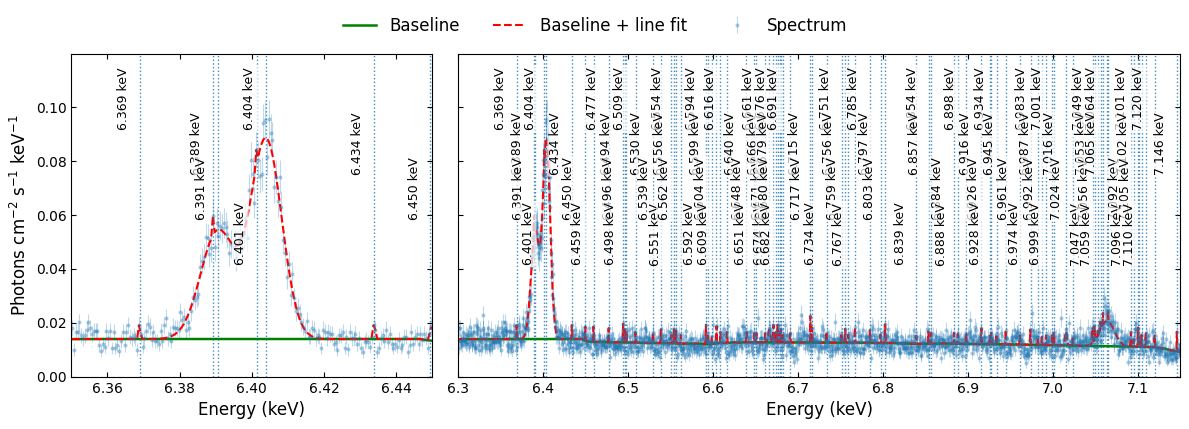

In [10]:
# ============================================================
# XRISM Fe zoom plot: two panels with fitted-line labels
# ============================================================
# ============================================================
# Helper functions
# ============================================================

def filter_bliss_lines_for_window(
    line_table,
    emin,
    emax,
    center_col="center",
    prob_col="cluster_probability",
    p_min=None,
    snr_min=None,
    snr_columns=("snr_peak", "snr_amplitude", "snr_area"),
    snr_mode="any",
    prob_snr_logic="and",
):
    """
    Select BLiSS lines whose fitted centroid lies inside an energy window.
    Optionally apply probability and/or SNR cuts.
    """

    if line_table is None or len(line_table) == 0:
        return pd.DataFrame()

    df = line_table.copy()

    if center_col not in df.columns:
        return pd.DataFrame(columns=df.columns)

    # --------------------------------------------------------
    # Numeric safety
    # --------------------------------------------------------

    numeric_cols = [center_col, prob_col] + list(snr_columns)

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # --------------------------------------------------------
    # Energy-window selection
    # --------------------------------------------------------

    mask_window = (
        np.isfinite(df[center_col])
        & (df[center_col] >= emin)
        & (df[center_col] <= emax)
    )

    # --------------------------------------------------------
    # Optional probability cut
    # --------------------------------------------------------

    if p_min is not None and prob_col in df.columns:
        mask_prob = (
            np.isfinite(df[prob_col])
            & (df[prob_col] >= p_min)
        )
    else:
        mask_prob = pd.Series(True, index=df.index)

    # --------------------------------------------------------
    # Optional SNR cut
    # --------------------------------------------------------

    available_snr_cols = [col for col in snr_columns if col in df.columns]

    if snr_min is not None and len(available_snr_cols) > 0:

        snr_matrix = df[available_snr_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

        if snr_mode == "any":
            mask_snr = (snr_matrix >= snr_min).any(axis=1)
        elif snr_mode == "all":
            mask_snr = (snr_matrix >= snr_min).all(axis=1)
        else:
            raise ValueError("snr_mode must be 'any' or 'all'.")

    else:
        mask_snr = pd.Series(True, index=df.index)

    # --------------------------------------------------------
    # Combine probability and SNR cuts
    # --------------------------------------------------------

    if prob_snr_logic == "and":
        mask_quality = mask_prob & mask_snr
    elif prob_snr_logic == "or":
        mask_quality = mask_prob | mask_snr
    else:
        raise ValueError("prob_snr_logic must be 'and' or 'or'.")

    # --------------------------------------------------------
    # Final selection
    # --------------------------------------------------------

    out = df.loc[mask_window & mask_quality].copy()
    out = out.sort_values(center_col).reset_index(drop=True)

    return out


def get_plot_line_label(row, mode="energy"):
    """
    Return the label used for vertical line annotations.

    mode = "energy", "ion", or "both"
    """

    center = pd.to_numeric(row.get("center", np.nan), errors="coerce")

    if np.isfinite(center):
        energy_label = f"{center:.3f} keV"
    else:
        energy_label = ""

    ion_label = ""

    for col in ["ion", "Ion", "most_probable_ion", "line_id", "Line ID"]:
        if col in row.index and pd.notna(row[col]):
            value = str(row[col]).strip()
            if value.lower() not in ["nan", "none", ""]:
                ion_label = value.replace("_", " ")
                break

    if mode == "energy":
        return energy_label

    if mode == "ion":
        return ion_label if ion_label != "" else energy_label

    if mode == "both":
        if ion_label != "":
            return f"{ion_label}\n{energy_label}"
        return energy_label

    raise ValueError("mode must be 'energy', 'ion', or 'both'.")


# ============================================================
# Configuration
# ============================================================

name = "XRISM"
window_name = "fe_6p0_7p5keV"
key = (name, window_name)

zoom_ranges = [
    (6.35, 6.45),
    (6.3, 7.15),
]

# Label options: "energy", "ion", or "both"
line_label_mode = "energy"
line_label_fontsize = 9

# Use post-global-fit line table
line_table = vela_window_global_lines.get(key, pd.DataFrame())

snr_columns = (
    "snr_peak",
    "snr_amplitude",
    "snr_area",
)

snr_mode = "any"
prob_snr_logic = "and"

try:
    figures_dir = NOTEBOOKS_DIR / "figures"
except NameError:
    figures_dir = Path("figures")

figures_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# Recover full spectrum
# ============================================================

spec = vela_spectra[name]

energy_full = np.asarray(spec["energy"], dtype=float)
values_full = np.asarray(spec["values"], dtype=float)
errors_full = np.asarray(spec["errors"], dtype=float)


# ============================================================
# Restrict to the Fe window used in the global fit
# ============================================================

emin, emax = energy_windows_victoria[window_name]

mask_window = (
    (energy_full >= emin)
    & (energy_full <= emax)
)

energy = energy_full[mask_window]
values = values_full[mask_window]
errors = errors_full[mask_window]

base = np.asarray(
    vela_window_baselines[key],
    dtype=float,
)

yfit = np.asarray(
    vela_window_yfit.get(key, np.zeros_like(energy)),
    dtype=float,
)

if len(base) != len(energy):
    raise ValueError(
        f"base and energy do not have the same length: "
        f"len(base)={len(base)}, len(energy)={len(energy)}"
    )

if len(yfit) != len(energy):
    yfit = np.zeros_like(energy)


# ============================================================
# Common y-axis limit
# ============================================================

global_ymax = 0.0

for xmin, xmax in zoom_ranges:

    mask_zoom = (
        (energy >= xmin)
        & (energy <= xmax)
    )

    if np.any(mask_zoom):
        ymax = np.nanmax(values[mask_zoom])
        if np.isfinite(ymax):
            global_ymax = max(global_ymax, ymax)

if global_ymax <= 0:
    global_ymax = np.nanmax(values) if len(values) > 0 else 1.0


# ============================================================
# Plot: one row, two zooms
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.2),
    sharey=True,
    squeeze=False,
    gridspec_kw={"width_ratios": [1, 2]},
)

axes = axes[0]

for ax, (xmin, xmax) in zip(axes, zoom_ranges):

    mask_zoom = (
        (energy >= xmin)
        & (energy <= xmax)
    )

    e = energy[mask_zoom]
    v = values[mask_zoom]
    err = errors[mask_zoom]
    b = base[mask_zoom]
    yf = yfit[mask_zoom]

    if len(e) == 0:
        ax.text(
            0.5,
            0.5,
            "No data",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        ax.set_xlim(xmin, xmax)
        ax.tick_params(direction="in", top=True, right=True)
        continue

    ylines = np.maximum(v - b, 0.0)

    # --------------------------------------------------------
    # Filter line table in this zoom window
    # --------------------------------------------------------

    lines_zoom = filter_bliss_lines_for_window(
        line_table,
        emin=xmin,
        emax=xmax,
    )

    # --------------------------------------------------------
    # Spectrum
    # --------------------------------------------------------

    ax.errorbar(
        e,
        v,
        yerr=err,
        fmt=".",
        markersize=4,
        linewidth=0.8,
        alpha=0.28,
        label="Spectrum",
    )

    # --------------------------------------------------------
    # Baseline
    # --------------------------------------------------------

    ax.plot(
        e,
        b,
        linewidth=1.8,
        label="Baseline",
        color="green"
    )

    # --------------------------------------------------------
    # Baseline + global fit
    # --------------------------------------------------------

    if len(yf) == len(e) and np.any(np.isfinite(yf)) and np.nanmax(yf) > 0:
        ax.plot(
            e,
            b + yf,
            linewidth=1.5,
            linestyle="--",
            color="red",
            label="Baseline + line fit",
        )

    # --------------------------------------------------------
    # Candidate / fitted line centroids
    # --------------------------------------------------------

    if len(lines_zoom) > 0:

        # y positions are alternated to reduce overlap between close labels
        label_y_positions = [0.96, 0.82, 0.68, 0.54]

        for i, (_, row) in enumerate(lines_zoom.iterrows()):

            center = pd.to_numeric(row.get("center", np.nan), errors="coerce")

            if not np.isfinite(center):
                continue

            label = get_plot_line_label(
                row,
                mode=line_label_mode,
            )

            if label == "":
                continue

            x_offset = 7 if i % 2 == 4 else -7
            ha = "left" if x_offset > 0 else "right"
            y_frac = label_y_positions[i % len(label_y_positions)]

            ax.axvline(
                center,
                linestyle=":",
                linewidth=1.0,
                alpha=0.85,
                zorder=3,
            )

            ax.annotate(
                label,
                xy=(center, y_frac),
                xycoords=("data", "axes fraction"),
                xytext=(x_offset, 0),
                textcoords="offset points",
                rotation=90,
                va="top",
                ha=ha,
                fontsize=line_label_fontsize,
                zorder=4,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.70,
                ),
            )

    # --------------------------------------------------------
    # Axes formatting
    # --------------------------------------------------------

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 1.25 * global_ymax)

    #ax.set_title(
    #    f"{name}: {xmin:.1f}--{xmax:.1f} keV",
    #    fontsize=11,
    #)

    ax.set_xlabel("Energy (keV)", fontsize=12)
    ax.tick_params(direction="in", top=True, right=True)


axes[0].set_ylabel(r"Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$", fontsize=12)


# ============================================================
# Legend
# ============================================================

handles, legend_labels = axes[0].get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    ncol=4,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
)

plt.tight_layout(rect=[0, 0, 1, 0.94])


# ============================================================
# Save
# ============================================================

fig.savefig(
    figures_dir / "xrism_fe_zoom_row_6p3_6p5_6p2_7p2keV.pdf",
    bbox_inches="tight",
)

fig.savefig(
    figures_dir / "xrism_fe_zoom_row_6p3_6p5_6p2_7p2keV.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

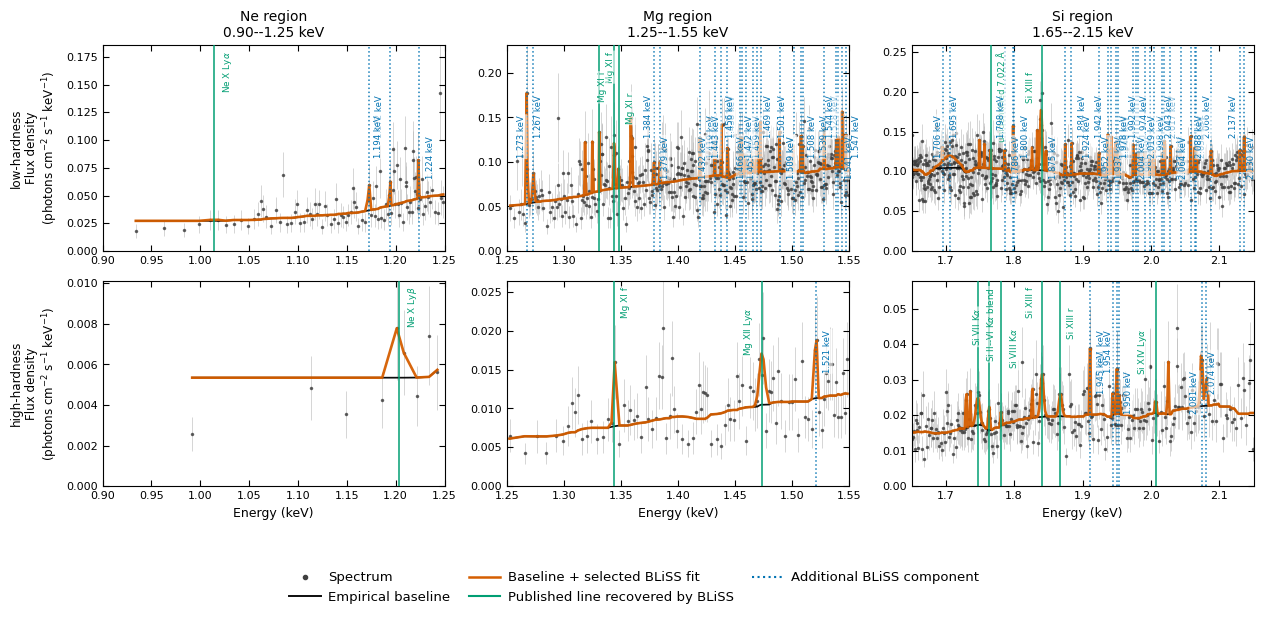

In [11]:
# ============================================================
# Chandra comparison plot after global fit:
# Victoria+BLiSS matched lines + additional global-fit lines
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# Visual configuration
# ============================================================

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

colors = {
    "spectrum": "0.25",
    "errors": "0.72",
    "baseline": "0.05",
    "global_fit": "#D55E00",   # orange / vermillion
    "matched": "#009E73",      # green
    "extra": "#0072B2",        # blue
}

show_line_labels = True

# Labels for the vertical lines:
# - "energy": show only fitted energy
# - "id": show Victoria/ion label if available
# - "both": show label + energy
matched_label_mode = "id"
extra_label_mode = "energy"

extra_match_tolerance_keV = 0.02


# ============================================================
# Configuration
# ============================================================

obs_order = [
    "Chandra low-hardness",
    "Chandra high-hardness",
]

window_order = [
    "ne_0p90_1p25keV",
    "mg_1p25_1p55keV",
    "si_1p65_2p15keV",
]

window_labels = {
    "ne_0p90_1p25keV": "Ne region\n0.90--1.25 keV",
    "mg_1p25_1p55keV": "Mg region\n1.25--1.55 keV",
    "si_1p65_2p15keV": "Si region\n1.65--2.15 keV",
}


# ============================================================
# Helpers
# ============================================================

def _get_first_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def latex_like_label(label):
    """Make common line labels prettier for plot annotations."""

    if pd.isna(label):
        return ""

    label = str(label).strip()

    replacements = {
        "Lyα": r"Ly$\alpha$",
        "Lyβ": r"Ly$\beta$",
        "Kα": r"K$\alpha$",
        "Kβ": r"K$\beta$",
        "II–VI": "II--VI",
        "_": " ",
    }

    for old, new in replacements.items():
        label = label.replace(old, new)

    return label


def format_vertical_label(center, label=None, mode="energy"):
    """Return label for vertical line annotations."""

    energy_label = f"{center:.3f} keV"

    if label is None or str(label).strip() == "":
        label = energy_label
    else:
        label = latex_like_label(label)

    if mode == "energy":
        return energy_label

    if mode == "id":
        return label

    if mode == "both":
        return f"{label}\n{energy_label}"

    raise ValueError("mode must be 'energy', 'id', or 'both'.")


def annotate_vertical_line(
    ax,
    center,
    label,
    color,
    y_frac=0.96,
    x_offset=5,
    fontsize=6.6,
    linestyle="-",
    linewidth=1.1,
    alpha=0.95,
):
    """Draw one vertical line and a slightly offset rotated label."""

    ax.axvline(
        center,
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        alpha=alpha,
        zorder=3,
    )

    if label is None or label == "":
        return

    ha = "left" if x_offset > 0 else "right"

    ax.annotate(
        label,
        xy=(center, y_frac),
        xycoords=("data", "axes fraction"),
        xytext=(x_offset, 0),
        textcoords="offset points",
        rotation=90,
        fontsize=fontsize,
        ha=ha,
        va="top",
        color=color,
        zorder=4,
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="none",
            alpha=0.60,
        ),
    )


def get_matched_bliss_centers(
    match_table,
    observation,
    window_name,
):
    """
    Return centers of BLiSS candidates matched to Victoria lines.
    """

    if match_table is None or len(match_table) == 0:
        return np.array([]), {}

    df = match_table.copy()

    obs_col = _get_first_existing_col(
        df,
        ["our_observation", "observation", "obs"],
    )

    window_col = _get_first_existing_col(
        df,
        ["window", "region"],
    )

    match_col = _get_first_existing_col(
        df,
        ["match_within_tolerance", "matched", "recovered"],
    )

    center_col = _get_first_existing_col(
        df,
        ["candidate_center", "candidate_center_keV", "center"],
    )

    lineid_col = _get_first_existing_col(
        df,
        ["line_id", "Line ID"],
    )

    if any(col is None for col in [obs_col, window_col, match_col, center_col]):
        return np.array([]), {}

    df = df[
        (df[obs_col] == observation)
        & (df[window_col] == window_name)
    ].copy()

    if len(df) == 0:
        return np.array([]), {}

    df[match_col] = df[match_col].fillna(False).astype(bool)
    df[center_col] = pd.to_numeric(df[center_col], errors="coerce")

    df = df[df[match_col] & np.isfinite(df[center_col])].copy()

    if len(df) == 0:
        return np.array([]), {}

    centers = np.sort(
        np.unique(
            np.round(df[center_col].to_numpy(dtype=float), 6)
        )
    )

    labels_by_center = {}

    if lineid_col is not None:
        for c in centers:
            close = df[np.abs(df[center_col] - c) < 1e-6]

            if len(close) > 0:
                labels_by_center[c] = latex_like_label(close.iloc[0][lineid_col])
            else:
                labels_by_center[c] = f"{c:.3f}"

    return centers, labels_by_center


def get_global_fit_centers(global_lines):
    """
    Return all global-fit line centers.
    """

    if global_lines is None or len(global_lines) == 0:
        return np.array([]), {}

    df = global_lines.copy()

    if "center" not in df.columns:
        return np.array([]), {}

    df["center"] = pd.to_numeric(df["center"], errors="coerce")
    df = df[np.isfinite(df["center"])].copy()

    if len(df) == 0:
        return np.array([]), {}

    centers = np.sort(
        np.unique(
            np.round(df["center"].to_numpy(dtype=float), 6)
        )
    )

    labels_by_center = {}

    ion_col = _get_first_existing_col(
        df,
        ["ion", "Ion", "most_probable_ion", "line_id", "Line ID"],
    )

    for c in centers:

        close = df[np.abs(df["center"] - c) < 1e-6]

        if len(close) == 0:
            labels_by_center[c] = f"{c:.3f}"
            continue

        if ion_col is not None and pd.notna(close.iloc[0][ion_col]):
            labels_by_center[c] = latex_like_label(close.iloc[0][ion_col])
        else:
            labels_by_center[c] = f"{c:.3f}"

    return centers, labels_by_center


def remove_centers_close_to_matched(
    centers,
    matched_centers,
    tolerance_keV=0.02,
):
    """
    Remove global-fit centers already represented by Victoria+BLiSS matched lines.
    """

    centers = np.asarray(centers, dtype=float)
    matched_centers = np.asarray(matched_centers, dtype=float)

    if len(centers) == 0:
        return np.array([])

    if len(matched_centers) == 0:
        return centers

    extra = []

    for c in centers:
        if np.all(np.abs(matched_centers - c) > tolerance_keV):
            extra.append(c)

    return np.asarray(extra, dtype=float)


# ============================================================
# Figure
# ============================================================

nrows = len(obs_order)
ncols = len(window_order)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.25 * ncols, 3.05 * nrows),
    sharex=False,
    sharey=False,
    squeeze=False,
)

for i, obs in enumerate(obs_order):

    spec = vela_spectra[obs]

    energy_full = np.asarray(spec["energy"], dtype=float)
    values_full = np.asarray(spec["values"], dtype=float)
    errors_full = np.asarray(spec["errors"], dtype=float)

    if "baseline" not in spec:
        raise ValueError(
            f"No baseline found in vela_spectra['{obs}']. "
            "Run the baseline cell first."
        )

    baseline_full = np.asarray(spec["baseline"], dtype=float)

    valid = (
        np.isfinite(energy_full)
        & np.isfinite(values_full)
        & np.isfinite(errors_full)
        & np.isfinite(baseline_full)
        & (errors_full > 0)
    )

    energy_full = energy_full[valid]
    values_full = values_full[valid]
    errors_full = errors_full[valid]
    baseline_full = baseline_full[valid]

    order = np.argsort(energy_full)

    energy_full = energy_full[order]
    values_full = values_full[order]
    errors_full = errors_full[order]
    baseline_full = baseline_full[order]

    for j, window_name in enumerate(window_order):

        ax = axes[i, j]

        key = (obs, window_name)

        emin, emax = energy_windows_victoria[window_name]

        mask = (
            (energy_full >= emin)
            & (energy_full <= emax)
        )

        energy = energy_full[mask]
        values = values_full[mask]
        errors = errors_full[mask]
        baseline = baseline_full[mask]

        if len(energy) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=9,
            )
            ax.set_xlim(emin, emax)
            ax.tick_params(direction="in", top=True, right=True)
            continue

        # ----------------------------------------------------
        # Global fit for this window
        # ----------------------------------------------------

        global_lines = vela_window_global_lines.get(key, pd.DataFrame())

        global_centers, global_labels = get_global_fit_centers(global_lines)

        yfit = np.asarray(
            vela_window_yfit.get(key, np.zeros_like(energy)),
            dtype=float,
        )

        if len(yfit) != len(energy):
            yfit = np.zeros_like(energy)

        # ----------------------------------------------------
        # Matched Victoria + BLiSS lines
        # ----------------------------------------------------

        matched_centers, matched_labels = get_matched_bliss_centers(
            victoria_chandra_candidate_matches,
            observation=obs,
            window_name=window_name,
        )

        extra_global_centers = remove_centers_close_to_matched(
            global_centers,
            matched_centers,
            tolerance_keV=extra_match_tolerance_keV,
        )

        # ----------------------------------------------------
        # Spectrum and baseline
        # ----------------------------------------------------

        ax.errorbar(
            energy,
            values,
            yerr=errors,
            fmt=".",
            color=colors["spectrum"],
            ecolor=colors["errors"],
            markersize=3.0,
            linewidth=0.55,
            alpha=0.75,
            zorder=1,
        )

        ax.plot(
            energy,
            baseline,
            color=colors["baseline"],
            linewidth=1.25,
            zorder=2,
        )

        # ----------------------------------------------------
        # Baseline + global fit
        # ----------------------------------------------------

        if np.any(np.isfinite(yfit)) and np.nanmax(yfit) > 0:
            ax.plot(
                energy,
                baseline + yfit,
                color=colors["global_fit"],
                linestyle="-",
                linewidth=1.9,
                alpha=0.95,
                zorder=2.5,
            )

        # ----------------------------------------------------
        # Victoria + BLiSS matched lines
        # ----------------------------------------------------

        for k, center in enumerate(matched_centers):

            raw_label = matched_labels.get(center, f"{center:.3f}")

            label = format_vertical_label(
                center,
                label=raw_label,
                mode=matched_label_mode,
            )

            y_frac = 0.97 - 0.10 * (k % 3)
            x_offset = 5 if k % 2 == 0 else -5

            annotate_vertical_line(
                ax,
                center=center,
                label=label if show_line_labels else "",
                color=colors["matched"],
                y_frac=y_frac,
                x_offset=x_offset,
                fontsize=6.4,
                linestyle="-",
                linewidth=1.15,
                alpha=0.95,
            )

        # ----------------------------------------------------
        # Additional global-fit lines
        # ----------------------------------------------------

        for k, center in enumerate(extra_global_centers):

            raw_label = global_labels.get(center, f"{center:.3f}")

            label = format_vertical_label(
                center,
                label=raw_label,
                mode=extra_label_mode,
            )

            y_frac = 0.76 - 0.10 * (k % 3)
            x_offset = 5 if k % 2 == 0 else -5

            annotate_vertical_line(
                ax,
                center=center,
                label=label if show_line_labels else "",
                color=colors["extra"],
                y_frac=y_frac,
                x_offset=x_offset,
                fontsize=6.1,
                linestyle=":",
                linewidth=1.10,
                alpha=0.90,
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_xlim(emin, emax)

        ymax = np.nanmax(values)

        if np.isfinite(ymax) and ymax > 0:
            ax.set_ylim(0, 1.30 * ymax)

        ax.tick_params(
            direction="in",
            top=True,
            right=True,
            length=4,
            width=0.8,
        )

        if i == 0:
            ax.set_title(
                window_labels.get(window_name, window_name),
                fontsize=10,
            )

        if j == 0:
            obs_label = obs.replace("Chandra ", "")
            ax.set_ylabel(
                rf"{obs_label}"
                "\n"
                r"Flux density"
                "\n"
                r"(photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$)",
                fontsize=8.6,
            )

        if i == nrows - 1:
            ax.set_xlabel("Energy (keV)")


# ============================================================
# Legend below panels
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=".",
        linestyle="None",
        color=colors["spectrum"],
        markersize=6,
        label="Spectrum",
    ),
    Line2D(
        [0],
        [0],
        color=colors["baseline"],
        linewidth=1.4,
        linestyle="-",
        label="Empirical baseline",
    ),
    Line2D(
        [0],
        [0],
        color=colors["global_fit"],
        linewidth=1.8,
        linestyle="-",
        label="Baseline + selected BLiSS fit",
    ),
    Line2D(
        [0],
        [0],
        color=colors["matched"],
        linewidth=1.5,
        linestyle="-",
        label="Published line recovered by BLiSS",
    ),
    Line2D(
        [0],
        [0],
        color=colors["extra"],
        linewidth=1.5,
        linestyle=":",
        label="Additional BLiSS component",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    fontsize=9.5,
    frameon=False,
    handlelength=2.4,
    columnspacing=1.4,
    handletextpad=0.55,
    bbox_to_anchor=(0.5, -0.015),
)

plt.tight_layout(rect=[0, 0.12, 1, 1.0])


# ============================================================
# Save
# ============================================================

try:
    figures_dir = NOTEBOOKS_DIR / "figures"
except NameError:
    figures_dir = Path("vela_line_search_results_windows") / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    figures_dir / "vela_x1_chandra_victoria_global_fit_comparison_grid.pdf",
    bbox_inches="tight",
    pad_inches=0.04,
)

fig.savefig(
    figures_dir / "vela_x1_chandra_victoria_global_fit_comparison_grid.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.04,
)

plt.show()